# Frequency-based comparison between Proteins dataset
In this example, you: 

1. Create proteins datasets from a Pandas data frame.
2. Calculate the frequency of records across experiments in each group.
3. Plot a venn diagram between two groups.

First you can install the library if missing, using ``pip``.

In [1]:
# !pip install omicspylib

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd

from omicspylib import ProteinsDataset, __version__
from omicspylib.plots import plot_density, plot_missing_values, plot_record_frequency, plot_venn2

print(f"omicspylib version: {__version__}")

omicspylib version: 0.2.0


Start with a tabular dataset containing only the protein identifier and the quantitative values per experiment. Additional annotation (e.g. protein names, gene names) can be stored elsewhere and merged back to the results in a later step.

In [3]:
data = pd.read_csv("data/protein_dataset.tsv", sep="\t")
data.head(3)

,protein_id,c1_rep1,c1_rep2,c1_rep3,c1_rep4,c1_rep5,c2_rep1,c2_rep2,c2_rep3,c2_rep4,c2_rep5,c3_rep1,c3_rep2,c3_rep3,c3_rep4,c3_rep5
0,p0,1748947.964,2655665.55,1812807.047,3179830.747,3002006.748,0.000,1357720.520,0.000,2087116.684,0.000,2558776.479,2655657.487,2115434.782,2889376.029,0.000
1,p1,1689613.957,0.00,1953790.640,2447525.246,2877005.859,1438315.297,1198347.576,1864606.985,0.000,1414141.418,0.000,3070691.996,3149289.453,0.000,2264704.900
2,p2,2053224.994,0.00,0.000,1729807.427,1307542.588,1062917.256,1466408.270,0.000,0.000,1461644.025,2538368.164,2136675.019,2565203.051,3772302.809,2793083.403


Create your dataset object by specifying the column name with the protein ids and the experimental condition groups.

In [4]:
conditions = {
    "c1": [f"c1_rep{i+1}" for i in range(5)],
    "c2": [f"c2_rep{i+1}" for i in range(5)],
    "c3": [f"c3_rep{i+1}" for i in range(5)],
}
dataset = ProteinsDataset.from_df(data, id_col="protein_id", conditions=conditions)
dataset.describe()

{'n_conditions_total': 3,
 'n_records_total': 100,
 'n_experiments_total': 15,
 'statistics_per_condition': [{'name': 'c1',
   'n_experiments': 5,
   'n_records': 100,
   'experiment_names': ['c1_rep1', 'c1_rep2', 'c1_rep3', 'c1_rep4', 'c1_rep5'],
   'n_records_per_experiment': [74, 73, 67, 71, 76]},
  {'name': 'c2',
   'n_experiments': 5,
   'n_records': 100,
   'experiment_names': ['c2_rep1', 'c2_rep2', 'c2_rep3', 'c2_rep4', 'c2_rep5'],
   'n_records_per_experiment': [71, 70, 67, 68, 80]},
  {'name': 'c3',
   'n_experiments': 5,
   'n_records': 100,
   'experiment_names': ['c3_rep1', 'c3_rep2', 'c3_rep3', 'c3_rep4', 'c3_rep5'],
   'n_records_per_experiment': [80, 73, 78, 74, 80]}]}

Perform basic exploratory analysis by passing the dataset to the relevant plotting functions. For example, you can plot the quantitative value distribution (raw or log transformed), or count the number of missing values per experiment. The output of plotting functions is a matplotlib's ``plt.Axes`` object. So, you can use standard matplotlib syntax to stylize it or combine with other plots.

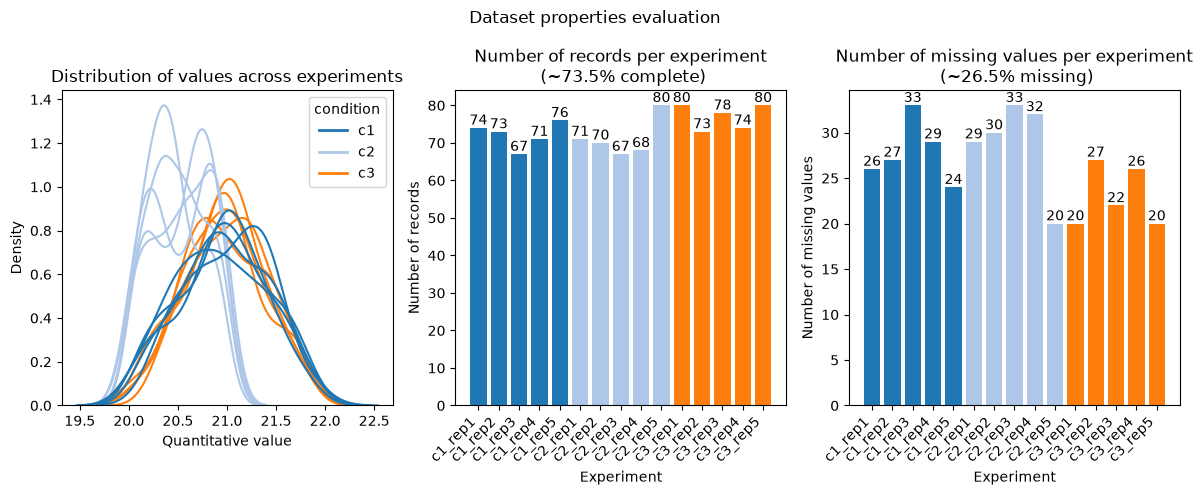

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
plot_density(dataset=dataset.log2_transform(), ax=ax[0])
plot_record_frequency(dataset=dataset, ax=ax[1], title="Number of records per experiment\n")
plot_missing_values(dataset=dataset, ax=ax[2], title="Number of missing values per experiment\n")
plt.suptitle("Dataset properties evaluation")
plt.tight_layout()
plt.show()

Calculate the number of unique entries per condition base on the min and max frequency thresholds.

In [6]:
from omicspylib import PairwiseUniqueEntryComparison

frequency_comparison = PairwiseUniqueEntryComparison(dataset, condition_a="c3", condition_b="c2")
frequency_results = frequency_comparison.eval(majority_grp_min_freq=1, minority_grp_max_freq=0)
frequency_results

,frequency_class
protein_id,
p0,common
p1,common
p10,common
p11,common
p12,common
...,...
p95,common
p96,common
p97,common


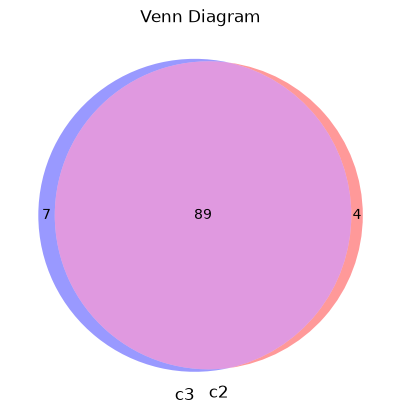

In [7]:
plot_venn2(frequency_results, condition_a="c3", condition_b="c2")
plt.show()

Finally export the dataset into a Pandasa data frame and join the results of the frequency comparison for further analysis.

In [8]:
output_df = dataset.to_table()
output_df = output_df.merge(frequency_results, left_index=True, right_index=True, how="outer")
output_df.head(4)

# output_df.to_csv('dest_dir/pairwise_comparison.csv', sep='\t', index=True)   # standard pandas flow

,c1_rep1,c1_rep2,c1_rep3,c1_rep4,c1_rep5,c2_rep1,c2_rep2,c2_rep3,c2_rep4,c2_rep5,c3_rep1,c3_rep2,c3_rep3,c3_rep4,c3_rep5,frequency_class
protein_id,,,,,,,,,,,,,,,,
p0,1748947.964,2655665.550,1812807.047,3179830.747,3002006.748,0.000,1357720.520,0.000,2087116.684,0.000,2558776.479,2655657.487,2115434.782,2889376.029,0.000,common
p1,1689613.957,0.000,1953790.640,2447525.246,2877005.859,1438315.297,1198347.576,1864606.985,0.000,1414141.418,0.000,3070691.996,3149289.453,0.000,2264704.900,common
p10,1757091.693,1536626.205,1149483.961,1600723.858,0.000,2052587.904,0.000,1374370.420,1297363.188,1402527.775,2571565.658,0.000,3648111.452,0.000,3233381.133,common
p11,2596847.916,2592526.227,2686205.008,0.000,2684964.779,1461644.369,1528602.809,1837379.574,1226512.744,1329202.688,1624380.375,0.000,1660887.127,1920664.243,1852346.381,common
